In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn.functional as F

from transformers import BertTokenizer, BertForMaskedLM, logging

logging.set_verbosity_error()


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# Import BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')
model = BertForMaskedLM.from_pretrained('bert-large-uncased').to(device)

model.eval();

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

# Implant hook

In [4]:
layer2shuffle = 100
target_token_id = 1

def implant_hook(layer_number):
    def hook(module, input, output):
        hs = output   # output is already a tensor here

        if layer_number == layer2shuffle:
            shuffled_idx = torch.randperm(hs.shape[-1], device=hs.device)
            if hs.ndim == 3:
                a = hs[0, target_token_id, :]
                hs[0, target_token_id, :] = a[shuffled_idx]
            elif hs.ndim == 2:
                a = hs[target_token_id, :]
                hs[target_token_id, :] = a[shuffled_idx]
            else:
                raise ValueError(f"Unexpected hs shape: {hs.shape}")

        return hs
    return hook

In [5]:
num_layers = model.config.num_hidden_layers

if 'hh' in 'globals()':
  for h in hh:
    h.remove()

hh = []

for layeri in range(num_layers):
  hh.append(model.bert.encoder.layer[layeri].register_forward_hook(implant_hook(layeri))) # high number to ensure that there is no shuffling

# Import text, tokenize and forward pass through the model

In [6]:
text = 'Pay no attention to that man [MASK] the curtain!'

tokens = tokenizer(text, return_tensors='pt').to(device)
masked_token_idx = torch.where(tokens.input_ids == tokenizer.mask_token_id)[1]
#
# Expected Response
actual_token = 'behind'
actual_token_id = tokenizer.convert_tokens_to_ids(actual_token)
#
for t in tokens['input_ids'][0]:
  print(f'{t:5} {tokenizer.decode(t)}\n')
#
print(f'\nThe mask is in token index {masked_token_idx}')

  101 [CLS]

 3477 pay

 2053 no

 3086 attention

 2000 to

 2008 that

 2158 man

  103 [MASK]

 1996 the

11002 curtain

  999 !

  102 [SEP]


The mask is in token index tensor([7], device='cuda:0')


In [7]:
# Forward-pass
layer2shuffle = 100 # This will be set by the loop
target_token_id = masked_token_idx

with torch.no_grad():
  out_pure = model(**tokens.to(device), output_hidden_states=True)

print(f'There are {len(out_pure.hidden_states)} hidden states,\neach of size {list(out_pure.hidden_states[2].shape)}')

There are 25 hidden states,
each of size [1, 12, 1024]


In [8]:
# predicted tokens
for i in range(len(tokens['input_ids'][0])):

  # the word in the original text
  actual = tokenizer.decode(tokens['input_ids'][0,i])

  # the predicted word
  predicted = tokenizer.decode(torch.argmax(out_pure.logits[0,i,:].detach().cpu(),dim=-1))

  # print!
  print(f'{actual:>12} predicted as "{predicted}"')

       [CLS] predicted as "."
         pay predicted as "pay"
          no predicted as "no"
   attention predicted as "attention"
          to predicted as ","
        that predicted as "that"
         man predicted as "man"
      [MASK] predicted as "behind"
         the predicted as "the"
     curtain predicted as "curtain"
           ! predicted as "!"
       [SEP] predicted as "."


# Test for all layers

In [9]:
actual_token_id, masked_token_idx

(2369, tensor([7], device='cuda:0'))

In [10]:
# Initialize
preds = torch.zeros((num_layers,2))

mask_pos = masked_token_idx.item()

target_token_id = masked_token_idx.item()

for layeri in range(num_layers):
  layer2shuffle = layeri # Update global layer2shuffle for the current iteration

  with torch.no_grad():
    out_shuffled = model(**tokens.to(device), output_hidden_states=True)

  # Log softmax of the logits
  lsm = F.log_softmax(out_shuffled.logits[0, mask_pos, :].detach().cpu(), dim=-1)
  preds[layeri,0] = lsm[actual_token_id]

  # predicted masked target
  preds[layeri,1] = torch.argmax(lsm, dim=-1)

In [11]:
for i in range(num_layers):
    pred_id = int(preds[i, 1].item())
    print(f'Shuffling Layer {i:3} led to prediction: {tokenizer.decode(pred_id)}')

Shuffling Layer   0 led to prediction: .
Shuffling Layer   1 led to prediction: and
Shuffling Layer   2 led to prediction: ,
Shuffling Layer   3 led to prediction: "
Shuffling Layer   4 led to prediction: -
Shuffling Layer   5 led to prediction: !
Shuffling Layer   6 led to prediction: .
Shuffling Layer   7 led to prediction: and
Shuffling Layer   8 led to prediction: !
Shuffling Layer   9 led to prediction: to
Shuffling Layer  10 led to prediction: !
Shuffling Layer  11 led to prediction: the
Shuffling Layer  12 led to prediction: !
Shuffling Layer  13 led to prediction: !
Shuffling Layer  14 led to prediction: !
Shuffling Layer  15 led to prediction: "
Shuffling Layer  16 led to prediction: i
Shuffling Layer  17 led to prediction: fast
Shuffling Layer  18 led to prediction: a
Shuffling Layer  19 led to prediction: .
Shuffling Layer  20 led to prediction: .
Shuffling Layer  21 led to prediction: -
Shuffling Layer  22 led to prediction: to
Shuffling Layer  23 led to prediction: and


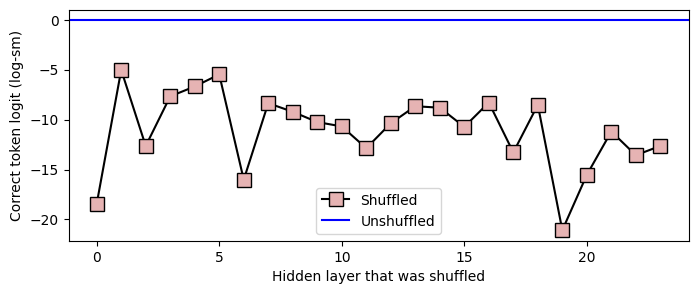

In [12]:
# log-softmax the unshuffled data
logsm = F.log_softmax(out_pure.logits[0,mask_pos,:].detach().cpu(),dim=-1)
pure_max_logit = logsm[actual_token_id]

# visualize
plt.figure(figsize=(8,3))
plt.plot(preds[:,0],'ks-',markerfacecolor=[.9,.7,.7],markersize=10,label='Shuffled')
plt.axhline(pure_max_logit,color='b',zorder=-4,label='Unshuffled')

plt.gca().set(xlabel='Hidden layer that was shuffled',ylabel='Correct token logit (log-sm)')
plt.legend()
plt.show()

# Implant hook to add noise to the hidden layer activations

In [13]:
layer2shuffle = 100
target_token_id = 1

def implant_hook(layer_number):
    def hook(module, input, output):
        hs = output   # output is already a tensor here

        if layer_number == layer2shuffle:
            if hs.ndim == 3:
                a = hs[0, target_token_id, :]
                noise = torch.randn_like(a) * a.std()*2
                hs[0, target_token_id, :] = a + noise
            elif hs.ndim == 2:
                a = hs[target_token_id, :]
                noise = torch.randn_like(a) * a.std()*2
                hs[target_token_id, :] = a + noise
            else:
                raise ValueError(f"Unexpected hs shape: {hs.shape}")

        return hs
    return hook

In [14]:
num_layers = model.config.num_hidden_layers

if 'hh' in 'globals()':
  for h in hh:
    h.remove()

hh = []

for layeri in range(num_layers):
  hh.append(model.bert.encoder.layer[layeri].register_forward_hook(implant_hook(layeri))) # high number to ensure that there is no shuffling

In [15]:
# Initialize
preds = torch.zeros((num_layers,2))

mask_pos = masked_token_idx.item()

target_token_id = masked_token_idx.item()

for layeri in range(num_layers):
  layer2shuffle = layeri # Update global layer2shuffle for the current iteration

  with torch.no_grad():
    out_shuffled = model(**tokens.to(device), output_hidden_states=True)

  # Log softmax of the logits
  lsm = F.log_softmax(out_shuffled.logits[0, mask_pos, :].detach().cpu(), dim=-1)
  preds[layeri,0] = lsm[actual_token_id]

  # predicted masked target
  preds[layeri,1] = torch.argmax(lsm, dim=-1)

In [16]:
for i in range(num_layers):
    pred_id = int(preds[i, 1].item())
    print(f'Shuffling Layer {i:3} led to prediction: {tokenizer.decode(pred_id)}')

Shuffling Layer   0 led to prediction: .
Shuffling Layer   1 led to prediction: .
Shuffling Layer   2 led to prediction: !
Shuffling Layer   3 led to prediction: to
Shuffling Layer   4 led to prediction: !
Shuffling Layer   5 led to prediction: i
Shuffling Layer   6 led to prediction: and
Shuffling Layer   7 led to prediction: please
Shuffling Layer   8 led to prediction: ,
Shuffling Layer   9 led to prediction: !
Shuffling Layer  10 led to prediction: .
Shuffling Layer  11 led to prediction: in
Shuffling Layer  12 led to prediction: -
Shuffling Layer  13 led to prediction: see
Shuffling Layer  14 led to prediction: .
Shuffling Layer  15 led to prediction: you
Shuffling Layer  16 led to prediction: -
Shuffling Layer  17 led to prediction: power
Shuffling Layer  18 led to prediction: .
Shuffling Layer  19 led to prediction: ,
Shuffling Layer  20 led to prediction: ,
Shuffling Layer  21 led to prediction: .
Shuffling Layer  22 led to prediction: notes
Shuffling Layer  23 led to predictio

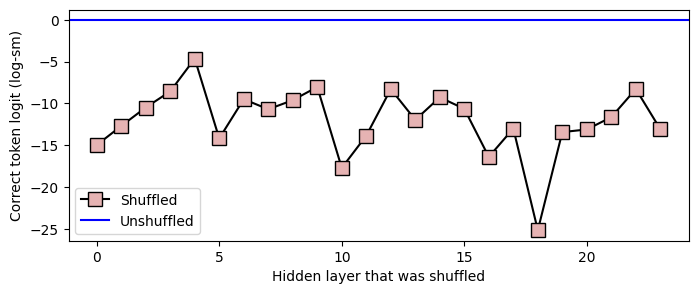

In [17]:
# log-softmax the unshuffled data
logsm = F.log_softmax(out_pure.logits[0,mask_pos,:].detach().cpu(),dim=-1)
pure_max_logit = logsm[actual_token_id]

# visualize
plt.figure(figsize=(8,3))
plt.plot(preds[:,0],'ks-',markerfacecolor=[.9,.7,.7],markersize=10,label='Shuffled')
plt.axhline(pure_max_logit,color='b',zorder=-4,label='Unshuffled')

plt.gca().set(xlabel='Hidden layer that was shuffled',ylabel='Correct token logit (log-sm)')
plt.legend()
plt.show()

# Distributions of activations and noise

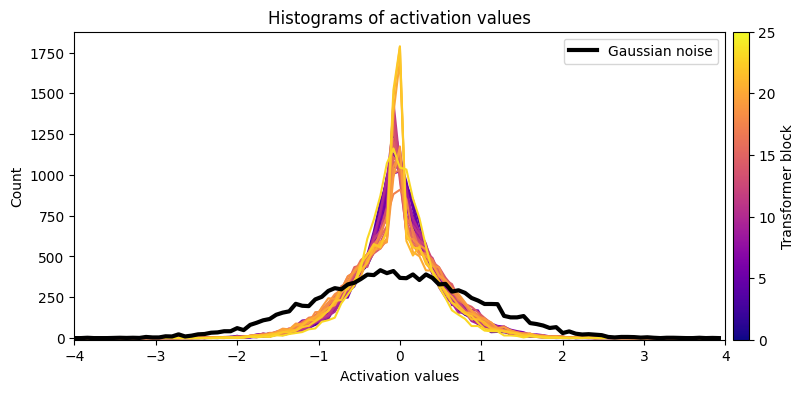

In [18]:
hs = out_pure.hidden_states

fig = plt.figure(figsize=(10,4))

# bins for the histogram
xvals4hist = np.linspace(-4,4,101)

# loop over layers
for i in range(1,len(hs)):

  # get the vectorized data
  vdat = hs[i].detach().cpu().numpy().flatten()

  # calculate and draw the histogram
  y,x = np.histogram(vdat,bins=xvals4hist)
  plt.plot(x[:-1],y,color=mpl.cm.plasma(i/(len(hs)+1)))

# and again for gaussian noise
noise = np.random.randn(len(vdat)) * vdat.std()*2
y,x = np.histogram(noise,bins=xvals4hist)
plt.plot(x[:-1],y,'k',linewidth=3,label='Gaussian noise')

# create a colorbar for the lines
norm = mpl.colors.Normalize(vmin=0,vmax=len(hs))
sm = mpl.cm.ScalarMappable(cmap=mpl.cm.plasma,norm=norm)
cbar = fig.colorbar(sm,ax=plt.gca(),pad=.01)
cbar.set_label(r'Transformer block')

# final touches
plt.legend()
plt.gca().set(xlabel='Activation values',ylabel='Count',xlim=xvals4hist[[0,-1]],
              ylim=[-10,None],title='Histograms of activation values')
plt.show()